R2 Score: 0.9193605975741711
Predicted House Price: 193046.83059150918


c:\Users\Sunil Kale\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


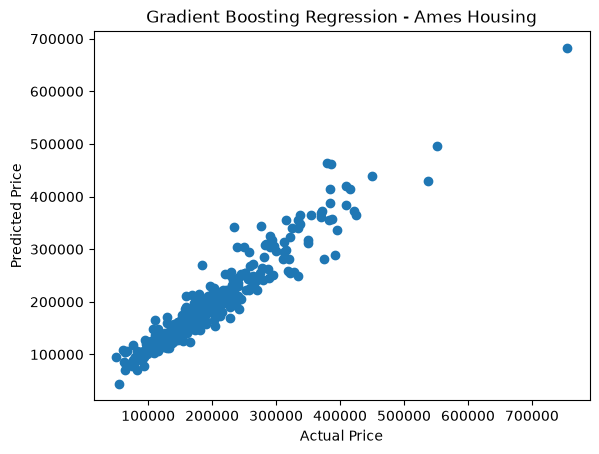

In [1]:
# #10. Implement House Price Prediction with Gradient Boosting
# Dataset Name: Ames Housing Dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("AmesHousing.csv")

# Convert ? to missing values
df = df.replace("?", pd.NA)

# Select numerical columns only
df = df.select_dtypes(include="number")

# Remove rows containing missing values
df = df.dropna()

# Remove identifier columns
df = df.drop(["Order", "PID"], axis=1)

# Independent variables
X = df.drop("SalePrice", axis=1)

# Target variable
y = df["SalePrice"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Gradient Boosting model
model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# R2 Score
print("R2 Score:", r2_score(y_test, y_pred))

# New house prediction
new_house = [X.iloc[0].values]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Boosting Regression - Ames Housing")
plt.show()